# Julia notebook to compute the buoyancy field using the 1D vertical diffusion equation, inspired by Peterson & Callies (2025, in review) theory. Then compute the associated geostrophic flow using the frictional thermal wind equation.

twnh Sep '25

This notebook solves the steady vertical diffusion problem with a Green's function.

The problem is to solve:
\begin{align}
\kappa \frac{d^2 b}{dz^2} 
    + \gamma \left( B(z) - b \right) & = 0 , 
\end{align}
for $b(z)$, given buoyancy profile $B(z)$, relaxation coefficient $\gamma$, with boundary conditions
\begin{align}
 \frac{db}{dz}  &= 0 \text{~ at~} z = -H , \\
 b &= 0 \text{~ at~} z = 0 ,
\end{align}
where bottom buoyancy gradient is be zero.

This problem is solved repeatedly for different $H(x)$ fields and $B(x,z)$ fields. This constructs a buoyancy field that varies in $(x,z)$ using the 1D diffusion equation.

Then, given $b(x,z)$, solve:

\begin{align}
- f \frac{d v}{d z} & = - \frac{\partial b}{\partial x} + \epsilon^2   \nu \frac{d^3 u}{d z^3}, \\
  f \frac{d u}{d z} & = - \frac{\partial b}{\partial y} + \epsilon^2   \nu \frac{d^3 v}{d z^3} , 
\end{align}
for $u(z), v(z)$, given viscosity $\nu$, and boundary conditions
\begin{align}
\text{Surface~}z = 0:
\begin{cases}
\displaystyle \epsilon^2 \nu \partial_z u & = \tau^x \\
\displaystyle  \epsilon^2 \nu \partial_z v & = \tau^y 
\end{cases}
 \\
\text{Bottom~}z = -H:
\begin{cases}
u & = 0  \\
v & = 0 
\end{cases} ,
\end{align}
where $(\tau^x, \tau^y)$ is the known wind stress.

THESE NOTES ARE INCOMPLETE. NEED TO DISCUSS HOW TO HANDLE THE UNDETERMINED CONSTANTS IN THE FRICTIONAL THERMAL WIND EQUATIONS...

See also: ``FindBuoyancyField.ipynb`` for the G's function solution to the 1D buoyancy equation, and ``FrictionalThermalWindSolution.ipynb`` for the G's function solution to the frictional thermal wind equation.

In [1]:
using SymPy
using Infiltrator

Define symbols and functions

In [2]:
# Geometry symbolic parameters:
z, ξ   = symbols("z ξ",   real=true, negative=true) # Vertical coordinate and source location (both in [-H,0])
x      = symbols("x",     real=true)                # Horizontal coordinate
H      = SymFunction("H", real=true)                # Domain depth H(x)
α      = 1//2                                       # Aspect ratio value. Note // which maintains rational type
Hfn    = α * (1 - x^2)                              # Bathymetry function
geometry_params = (H(x), z, ξ, α, x)

# Frictional thermal wind equation symbolic parameters:
f, ϵ   = symbols("f ϵ",   real=true, positive=true) # Coriolis parameter and Ekman number
ν₀     = symbols("ν₀",    real=true, positive=true) # Viscosity parameters
τˣ, τʸ = symbols("τˣ τʸ", real=true)                # Surface wind stress components

# Define viscosity profile here:
ν = ν₀                                              # Constant viscosity profile

uv_params = (f, ϵ, ν, τˣ, τʸ)

# Buoyancy equation symbolic parameters:
κ₀     = symbols("κ₀",    real=true, positive=true) # Diffusivity parameters
γ      = symbols("γ",     real=true, positive=true) # Relaxation parameter

# Define diffusivity profile here:
κ = κ₀                                              # Constant viscosity profile

b_params = (κ, γ) ;

### Set the problem parameters here:

In [3]:
# Define the $B(z)$ source term here:
B      = SymFunction("B")                           # Source term function B(z): buoyancy field relaxation profile.
Bfn  = z                                               # Linear profile with vanishing surface buoyancy


f_val  = 1.0
ϵ_val  = 1.0

γ_val  = 1.0

κ₀_val = 0.04

ν₀_val = κ₀_val

τˣ_val = 0.0
τʸ_val = 0.0
param_values = Dict(f=>f_val, ϵ=>ϵ_val, γ=>γ_val, κ₀=>κ₀_val, ν₀=>ν₀_val, τˣ=>τˣ_val, τʸ=>τʸ_val)

Dict{Sym{PyCall.PyObject}, Float64} with 7 entries:
  γ  => 1.0
  κ₀ => 0.04
  ϵ  => 1.0
  τˣ => 0.0
  ν₀ => 0.04
  f  => 1.0
  τʸ => 0.0

Code to solve the buoyancy equation using a Green's function:

In [4]:
function compute_Gb(b_params, geometry_params, param_values)
    # Setup symbols and parameters:
    κ, γ          = b_params
    H, z, ξ, α, x = geometry_params
    b             = SymFunction("b")
    A             = symbols("A",     real=true)                      # Unknown coefficient in the Green's function solution
    im            = SymPy.im  # SymPy's imaginary unit
    
    #0. Define the ODE for b(z):
    ode = Eq(κ * diff(diff(b(z),z),z) - diff(κ,z) * diff(b(z),z) - γ * b(z), 0)

    # 1. Solve for $G_- (z)$ on $-H \le z \le \xi$:
    bm = dsolve(ode, b(z), ics = Dict(diff(b(z),z).subs(z,-H)=>0)).rhs
    @assert simplify(diff(bm,z).subs(z,-H) - 0) == 0              # Check Neumann BC at bottom
    bm_const = filter(x -> startswith(string(x), "C"), bm.free_symbols)
    
    bm = bm.subs(first(bm_const), A)                              # Replace constant with A so it doesn't conflict later

    # 2. Solve for $G_+(z)$ on  $\xi \le z \le 0$:
    bp = dsolve(ode, b(z), ics = Dict(b(0)=>0) ).rhs
    @assert simplify(bp.subs(z,0)) == 0                           # Check Dirichlet BC at top

    # 3. Compute Wronskian $W(z)$:
    W = simplify(bm * diff(bp, z) - bp * diff(bm, z))

    # 4. Compute Green's function $G(z; \xi)$:
    Gm = simplify(bm * bp.subs(z,ξ) / (κ.subs(z,ξ) * W.subs(z,ξ)))
    Gp = simplify(bm.subs(z,ξ) * bp / (κ.subs(z,ξ) * W.subs(z,ξ)))

    # Check continuity and jump condition:
    @assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
    @assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1/κ.subs(z,ξ) == 0

    # Define piecewise Green's function:
    G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))

    # Check boundary conditions are satisfied
    @assert simplify(diff(G,z).subs(z,-H).subs(ξ,-H//3).subs(H,1//2)) == 0
    @assert simplify(G.subs(z,0).subs(ξ,-H//3)) == 0

    return G
end

compute_Gb (generic function with 1 method)

Code to solve the frictional thermal wind equation using a Green's function:

THIS ISN'T RIGHT!  THERE SHOULD BE THREE (NOT TWO) MATCHING CONDITIONS TO SPECIFY THE GREEN'S FUNCTION FOR THE THIRD ORDER EQUATION.

In [ ]:
function compute_Guv(uv_params, geometry_params, param_values)
    # Setup symbols and parameters:
    f, ϵ, ν, τˣ, τʸ = uv_params
    H, z, ξ, α, x   = geometry_params
    uv              = SymFunction("uv")
    A               = symbols("A",     real=true)                      # Unknown coefficient in the Green's function solution
    B               = symbols("B",     real=true)                      # Unknown coefficient in the Green's function solution
    im              = SymPy.im                                         # SymPy's imaginary unit

    #0. Define the ODE for uv(z):
    ode = Eq(f * diff(uv(z),z) + ϵ^2 * im * diff(diff(ν * diff(uv(z),z),z),z), 0)
    
    # 1. Solve for $G_- (z)$ on $-H \le z \le \xi$:
    Gₘ = dsolve(ode, uv(z), ics = Dict(uv(-H)=>0)).rhs
    @assert simplify(Gₘ.subs(z,-H)) == 0                                            # Check bottom BC
    # Replace constant names because otherwise they can interfere with the constants from the next dsolve below.
    const_names = [string(s) for s in Gₘ.free_symbols if occursin(r"^C\d+", string(s))]
    Gₘ = Gₘ.subs([(const_names[1],A),(const_names[2],B)])

    # 2. Solve for $G_+(z)$ on  $\xi \le z \le 0$:
    Gₚ = dsolve(ode, uv(z), ics = Dict(diff(uv(z),z).subs(z,0)=>0)).rhs               # This is where surface forcing would go.
    @assert simplify(diff(Gₚ,z).subs(z,0)) == 0                                     # Check surface BC

    # Eliminate two of the unknown coefficients by imposing continuity and the jump of the derivatives at z = ξ
    # WARNING!!!  NEED TO ALSO IMPOSE ANOTHER MATCHING CONDITION HERE BECAUSE THIS IS A THIRD ORDER ODE, NOT SECOND ORDER.
    cont_eq  = Gₘ.subs(z,ξ) - Gₚ.subs(z,ξ)
    deriv_eq = diff(Gₚ,z).subs(z,ξ) - diff(Gₘ,z).subs(z,ξ) + 1
    sol = solve([cont_eq, deriv_eq], [A,B], dict=true)[1]       # returns a Dict with solutions for C₁, C₃
    Gm = simplify(Gₘ.subs(A,simplify(sol[A])).subs(B,sol[B]))   # substitute for A and B in terms of C₁, C₃
    Gp = Gₚ

    # Check continuity and jump condition:
    @assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
    @assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) - 1 == 0

    # Define piecewise Green's function:
    G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))
    
    # Check boundary conditions:
    @assert simplify(G.subs([(z,-H),(ξ,-H//2)]).subs(H,1//2)) == 0        # Use sample values for ξ and H
    @assert simplify(diff(G,z).subs(z,0).subs(ξ,-H//2)) == 0

    # G_num = G.subs(param_values)
    return G
end

compute_Guv (generic function with 1 method)

# Compute the G's functions:

In [6]:
Gb_sym  = compute_Gb(b_params,geometry_params,param_values) 
Gb_num  = Gb_sym.subs(param_values).subs(H(x),Hfn)
display(Gb_sym)
Guv_sym = compute_Guv(uv_params,geometry_params,param_values) 
display(Guv_sym)
Guv_num = Guv_sym.subs(param_values).subs(H(x),Hfn) ;

//          ___   \ /     ___                ___ \    ___                    
||     -2*\/ γ *ξ | | 2*\/ γ *H(x)    -2*z*\/ γ  |  \/ γ *(z + ξ)            
||     -----------| | ------------    -----------|  -------------            
||         ____   | |      ____           ____   |       ____                
||       \/ κ₀    | |    \/ κ₀          \/ κ₀    |     \/ κ₀                 
|\1 - e           /*\e             + e           /*e                         
|----------------------------------------------------------------  for z <= ξ
|                              /     ___         \                           
|                              | 2*\/ γ *H(x)    |                           
|                              | ------------    |                           
|                              |      ____       |                           
|                   ___   ____ |    \/ κ₀        |                           
|               2*\/ γ *\/ κ₀ *\e             + 1/              

//        ___   ___             ___   ___                        ___   ___     >
||      \/ I *\/ f *z         \/ I *\/ f *(2*z + H(x))         \/ I *\/ f *(2* >
||      -------------         ------------------------         --------------- >
||          ____                        ____                             ____  >
||        \/ ν₀ *ϵ                    \/ ν₀ *ϵ                         \/ ν₀ * >
|\C1*f*e              - C1*f*e                         - C1*f*e                >
|----------------------------------------------------------------------------- >
|                                                                              >
|                                                                              >
|                                                                              >
<                                                                              >
|                                                                              >
|                           

## Solve for the buoyancy profile $b(z)$ and its derivative $\partial_x b$ using the buoyancy Green's function:

In [7]:
# Be careful with this function!!!
# It's more powerful than the .subs() method, but is more risky.
function tom_subs(expr,param_values)
    new_expr_str = string(expr)
    for (k, v) in param_values
        new_expr_str = replace(new_expr_str, string(k) => string(v))
    end
    return sympify(new_expr_str)
end

function get_var_in_expr(var,expr)
    filter(s -> string(s) == var, collect(expr.free_symbols))[1]
end

# Compute full symbolic expressions with no substitutions:
b_sym0 = simplify(integrate(-Gb_sym * γ * B(ξ), (ξ,-H(x),0) ))
b_sym  = tom_subs(b_sym0,Dict("Min(0, -H(x))"=>"-H(x)","Max(z, -H(x))"=>"z","Min(0, z)"=>"z")).args[1].args[1]      # Replace various pieces and select the z>-H part.
display(b_sym)
db_symdx = diff(b_sym(x),x)
display(db_symdx)

# Compute symbolic expressions with maximal substitutions:
b        = simplify(integrate(-Gb_sym * γ * Bfn.subs(z,ξ), (ξ,-H(x),0) ))
b_num    = simplify(b.subs(param_values).subs(H(x),Hfn)) 

# The order here is tricky!  Check carefully!
db_numdx = tom_subs(db_symdx,Dict("B(-H(x))"=>string(Bfn(-Hfn(x)))))
db_numdx = tom_subs(db_numdx,Dict("H(x)"=>string(Hfn)))
db_numdx = tom_subs(db_numdx,Dict("B(ξ)"=>string(Bfn.subs(z,ξ))))
db_numdx = tom_subs(db_numdx,param_values)
db_numdx = simplify(db_numdx) ;

      /                              /  z                        z             >
      |                              |  /                        /             >
      |                              | |                        |              >
      |/         ___\ /     ___    \ | |           ___          |          ___ >
      ||     z*\/ γ | | z*\/ γ     | | |        -\/ γ *ξ        |        \/ γ  >
      ||     -------| | -------    | | |        ---------       |        ----- >
      ||       ____ | |   ____     | | |           ____         |              >
  ___ ||     \/ κ₀  | | \/ κ₀      | | |         \/ κ₀          |              >
\/ γ *|\1 - e       /*\e        + 1/*| |  B(ξ)*e          dξ +  |  B(ξ)*e      >
      |                              | |                        |              >
      |                              |/                        /               >
      \                              \                                         >
----------------------------

      /          /    0                        0                 \             >
      |          |    /                        /                 |             >
      |          |   |                        |                  |             >
      |          |   |           ___          |          ___     |      ___    >
      |          |   |        -\/ γ *ξ        |        \/ γ *ξ   |  2*\/ γ *(z >
      |          |   |        ---------       |        -------   |  ---------- >
      |          |   |           ____         |          ____    |          __ >
      |      ___ |   |         \/ κ₀          |        \/ κ₀     |        \/ κ >
      |  2*\/ γ *|-  |  B(ξ)*e          dξ +  |  B(ξ)*e        dξ|*e           >
      |          |   |                        |                  |             >
      |          |  /                        /                   |             >
  ___ |          \                                               /             >
\/ γ *|- -------------------

# Make plot of Green's functions for sample parameters

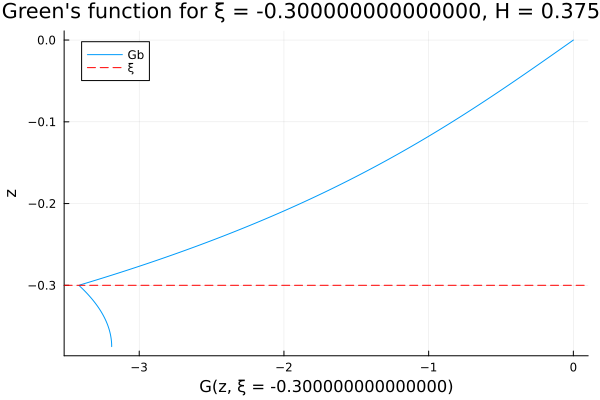

In [8]:
using Plots

this_x = -0.5
this_H = Hfn(this_x)
this_ξ = -this_H * 0.8           # Pick the value of ξ in [-H, 0]:

# Insert parameter values here and convert symbolic the symbolic G's function to a Julia function:
Gb_fixed(zᵢ,this_ξ) = Gb_num.subs([(ξ, this_ξ), (z, zᵢ),(x,this_x)])

# --- Plot ---
zvals = range(-this_H, 0, length=512)
Gbvals = [Gb_fixed(z_, this_ξ) |> float   for z_ in zvals]  # use float() to get a number
plt1 = plot(Gbvals, zvals; label="Gb",ylabel="z", xlabel="G(z, ξ = $this_ξ)", title="Buoyancy Green's function for ξ = $this_ξ, H = $this_H", legend=true)
hline!([this_ξ]; label="ξ", linestyle=:dash, color=:red)

# Plot diffusivity, viscosity, and buoyancy, and buoyancy derivative profiles

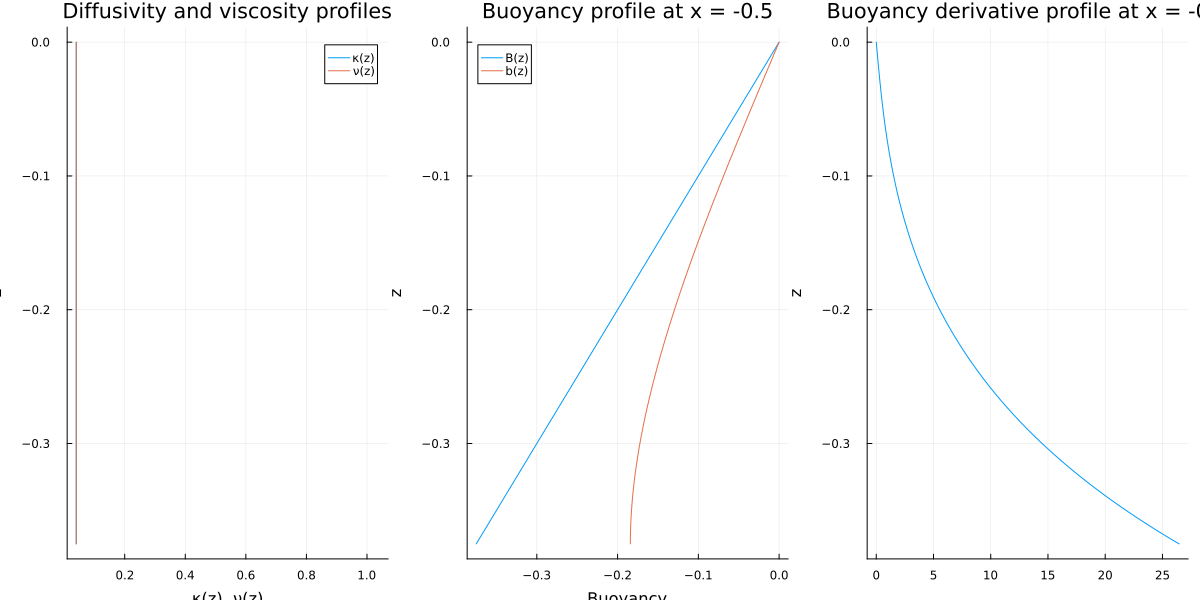

In [9]:
# Compute and plot diffusivity and viscosity:
κ_fixed(zᵢ) = κ.subs(param_values).subs([(H, this_H), (z, zᵢ)])
ν_fixed(zᵢ) = ν.subs(param_values).subs([(H, this_H), (z, zᵢ)])
κvals = [κ_fixed(z_) |> float for z_ in zvals]
νvals = [ν_fixed(z_) |> float for z_ in zvals]
# plt1 = plot(  κvals, zvals; label="κ(z)", ylabel="z", xlabel="κ(z), ν(z)", title="Diffusivity and viscosity profiles", xlims=(0,maximum(vcat(κvals,νvals)) * 1.1), ylims=(-this_H,0) )
plt1 = plot(  κvals, zvals; label="κ(z)", ylabel="z", xlabel="κ(z), ν(z)", title="Diffusivity and viscosity profiles")

plot!( νvals, zvals; label="ν(z)")

# Compute and plot relaxation buoyancy profile:
B_fixed(zᵢ) = Bfn.subs([(z, zᵢ)])
Bvals = [B_fixed(z_) |> float for z_ in zvals]
# plt2 = plot( Bvals, zvals, label="B(z)", ylabel="z", title="Buoyancy profile at x = $this_x", legend=false, xlims=(minimum(Bvals) * 1.1,maximum(Bvals) * 1.1), ylims=(-this_H,0))
plt2 = plot( Bvals, zvals, label="B(z)", ylabel="z", title="Buoyancy profile at x = $this_x", legend=false)

# Compute buoyancy profile at this_x, then plot:
function compute_b_profile(b_num, db_numdx, this_x, zvals)
    this_H         = Hfn(this_x)
    this_b         = simplify(b_num.subs(x,this_x))
    @assert simplify(diff(this_b,z).subs(z,-this_H)) < 1e-12            # Check Neumann BC at bottom
    @assert simplify(this_b.subs(z,0)) < 1e-12                          # Check Dirichlet BC at top    
    b_fixed(zᵢ)    = this_b.subs(z, zᵢ)

    # x_in_expr = filter(s -> string(s) == "x", collect(db_numdx.free_symbols))[1]         # There's more than one "x" which are treated differently, so .subs(x,this_x) substitution fails...
    # z_in_expr = filter(s -> string(s) == "z", collect(db_numdx.free_symbols))[1]
    x_in_expr = get_var_in_expr("x",db_numdx)
    z_in_expr = get_var_in_expr("z",db_numdx)
    this_dbdx      = simplify(db_numdx.subs(x_in_expr,this_x))
    dbdx_fixed(zᵢ) = this_dbdx.subs(z_in_expr, zᵢ)

    these_z_inds   = findall(zvals .>= -this_H)                           # Only compute down to the local depth
    these_z_vals   = zvals[these_z_inds]
    bvals          = [b_fixed(z_) |> float for z_ in these_z_vals]
    dbdxvals       = [dbdx_fixed(z_) |> float for z_ in these_z_vals]
    return bvals, dbdxvals, these_z_inds
end
b_vals, dbdx_vals, _ = compute_b_profile(b_num, db_numdx, this_x, zvals)
plot!(b_vals, zvals, label="b(z)", xlabel="Buoyancy", legend=true)

# Plot buoyancy derivative
plt3 = plot(dbdx_vals, zvals,  label="db(z)/dx", ylabel="z", title="Buoyancy derivative profile at x = $this_x", legend=false)
plot(plt1, plt2, plt3, layout=(1,3), size=(1200,600))

### Plot the buoyancy and buoyancy derivative fields by looping over different depths to construct them:

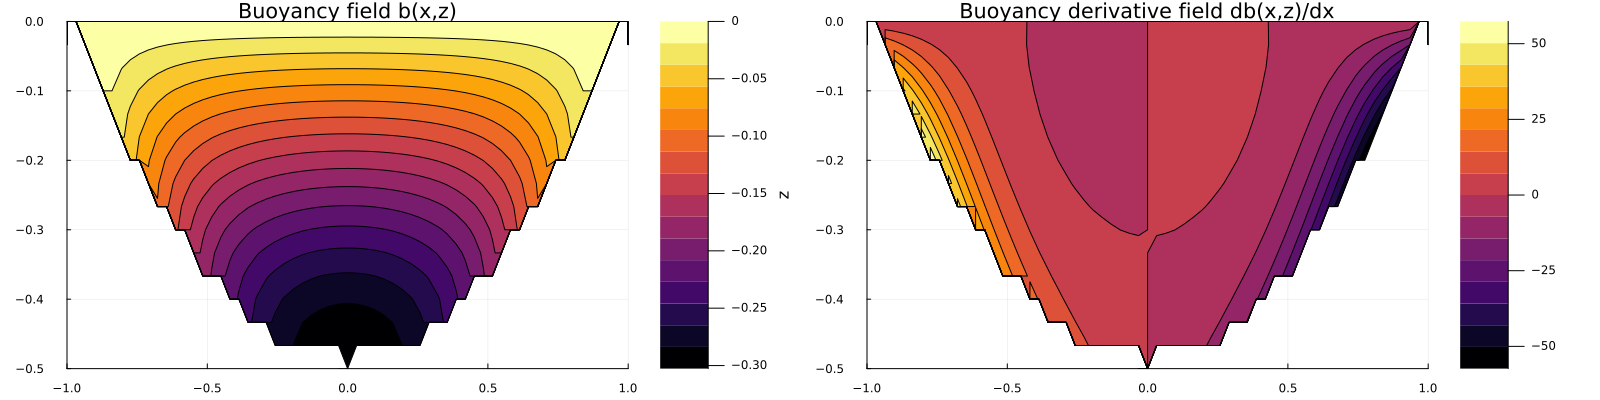

In [10]:
N = 16
# N = 8
xvals  = collect(range(-1, 0, length=2*N))
zvals  = float(collect(range(-maximum(Hfn.(collect(xvals))), 0; length=N)))
H_vals = float(Hfn.(collect(xvals)))
bz     = fill(NaN, length(zvals), length(xvals))
dbzdx  = fill(NaN, length(zvals), length(xvals))

for (x_ind, this_x) ∈ enumerate(xvals)
    b_values, dbdx_values, these_z_inds = compute_b_profile(b_num, db_numdx, this_x, zvals)
    bz[   these_z_inds, findfirst(==(this_x), xvals)] = b_values                 # Store b(x,z)
    dbzdx[these_z_inds, findfirst(==(this_x), xvals)] = dbdx_values              # Store dbdx(x,z)
end
# Assume symmetry to make plot look better:
plt_xvals = vcat(xvals[  1:end-1], -reverse(xvals))
plt_zvals = zvals
plt_bz    = hcat(   bz[:,1:end-1],  reverse(bz,   dims=2))
plt_dbzdx = hcat(dbzdx[:,1:end-1], -reverse(dbzdx,dims=2))
plt1 = contour(plt_xvals, plt_zvals, plt_bz;    xlabel="x", ylabel="z", title="Buoyancy field b(x,z)"               , fill=true)
plt2 = contour(plt_xvals, plt_zvals, plt_dbzdx; xlabel="x", ylabel="z", title="Buoyancy derivative field db(x,z)/dx", fill=true)
plot(plt1, plt2, layout=(1,2), size=(1600,400))

### Compute baroclinic potential energy $\chi (x)$ and plot it:

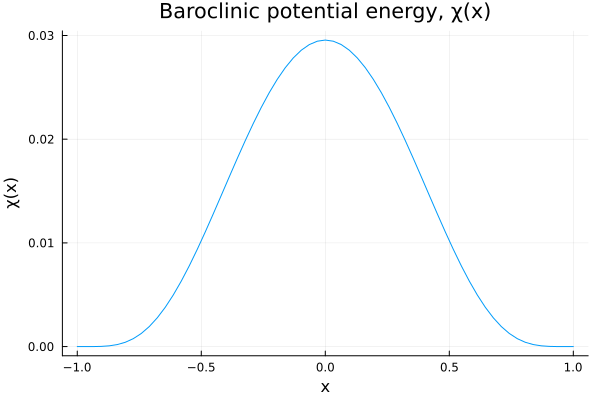

In [11]:
χ = fill(NaN, length(xvals))

for (x_ind, this_x) ∈ enumerate(xvals)
    local this_b = b_num.subs(x, this_x)
    local this_H = Hfn.subs(  x, this_x)
    χ[x_ind] = integrate(z * this_b,(z,-this_H,0))
end
plt_χ = vcat(χ[  1:end-1], reverse(χ))
plt = plot(plt_xvals,plt_χ;xlabel="x",ylabel="χ(x)",title="Baroclinic potential energy, χ(x)",legend=false)
display(plt)

# Resume work here!

It's proving VERY hard for SymPy to solve for the integrated uv_sym or uv_num expressions...It chokes on the integration.

In [12]:
# Try to compute the uv solution while carrying the unknown integration constants....

integrand0_sym = Guv_sym * db_symdx
# uv_sym          = integrate(integrand0_sym,(ξ,-H(x),0))     # Find formula for uv (still with 2 unknown constants).
integrand0_num = tom_subs(integrand0_sym,param_values)
integrand1_num = tom_subs(integrand0_num,Dict("Derivative(H(x), x)"=>string(diff(Hfn,x))))
integrand2_num = tom_subs(integrand1_num,Dict("B(-H(x))"=>string(Bfn(-Hfn(x)))))
integrand3_num = tom_subs(integrand2_num,Dict("H(x)"=>string(Hfn)))
integrand4_num = tom_subs(integrand3_num,Dict("B(ξ)"=>string(Bfn.subs(z,ξ))))

# For a particular (x,z) value:
integrand5_num = integrand4_num.subs(get_var_in_expr("x",integrand4_num),this_x)
integrand6_num = integrand5_num.subs(get_var_in_expr("z",integrand5_num),this_x/2)
@time uv_num = integrate(integrand6_num,(get_var_in_expr("ξ",integrand6_num),-Hfn(this_x),0))           # This doesn't evaluate to a function of the unknown constants.

# Try substituting specific C_1, C_3 values...
integrand7_num = integrand6_num.subs(get_var_in_expr("C1",integrand6_num),1.0)
integrand8_num = integrand7_num.subs(get_var_in_expr("C3",integrand7_num),2.0)
@time uv_num2 = integrate(integrand8_num,(get_var_in_expr("ξ",integrand8_num),-Hfn(this_x),0))           

Infiltrating top-level frame



FieldError: FieldError: type REPL.BasicREPL has no field `history_file`, available fields: `terminal`, `waserror`, `frontend_task`

In [13]:

# # Simplify the symbolic integrand by hand
# tmp_str1 = string(integrand0_sym)
# tmp_str2 = replace(tmp_str1,"Min(0, -H(x))" => "-H(x)")
# tmp_str3 = replace(tmp_str2,"Heaviside(H(x))" => "1")
# test_sym = sympify(tmp_str3)
# # this_int       = simplify(integrand0_num.subs(x,this_x))


# dbdx_num       = diff(b_num,x).subs(z,ξ)
# integrand0_num = Guv_num * dbdx_num
# this_int       = simplify(integrand0_num.subs(x,this_x))

# str_int = string(this_int)
# str_int2 = replace(str_int,  "Max(-0.375, ξ)" => "ξ")
# str_int3 = replace(str_int2, "Heaviside(-(ξ + 0.375))" => "1")
# this1 = sympify(str_int3)

# # uv          = integrate(this1,(ξ,-this_H,0))     # Find formula for uv (still with 2 unknown constants).